<a href="https://colab.research.google.com/github/poojithapalagani/Employee_Attrition_Analysis/blob/main/Employee_Attrition_FinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# importing libraries
import pandas as pd

In [ ]:
# Load data set
df = pd.read_csv("capstone_employee_attrition_dataset.csv",encoding='latin1')

In [ ]:
# check shape
print(df.shape)

(20000, 29)


In [ ]:
# View data
df.head()

,employee_id,age,gender,marital_status,education,education_field,department,job_role,job_level,business_travel,...,training_times_last_year,environment_satisfaction,job_satisfaction,work_life_balance,job_involvement,relationship_satisfaction,performance_rating,overtime,attrition,join_date
0,10000,41,Male,Married,2,Medical,Research & Development,Research Scientist,2,Travel_Rarely,...,1,1,4,3,3,1,4,No,Yes,2018-06-21
1,10001,32,Female,Divorced,2,Other,Sales,Manager,1,Travel_Rarely,...,0,4,2,1,3,3,3,No,No,2017-03-26
2,10002,35,Female,Married,4,Other,Research & Development,Healthcare Representative,2,Non-Travel,...,2,3,4,3,2,2,4,No,No,2019-10-18
3,10003,36,Female,Married,3,Technical Degree,Research & Development,Laboratory Technician,2,Non-Travel,...,3,3,2,2,1,3,3,No,Yes,2017-03-06
4,10004,33,Male,Married,5,Other,Sales,Sales Representative,1,Travel_Rarely,...,2,1,2,3,4,4,3,No,Yes,2016-11-29


In [ ]:
# check data types
df.dtypes

,0
employee_id,int64
age,int64
gender,object
marital_status,object
education,int64
education_field,object
department,object
job_role,object
job_level,int64
business_travel,object


In [ ]:
#Missing values
df.isnull().sum()

,0
employee_id,0
age,0
gender,0
marital_status,0
education,0
education_field,0
department,0
job_role,0
job_level,0
business_travel,0


In [ ]:
df["attrition"].value_counts()

,count
attrition,
No,12067
Yes,7933


In [ ]:
#Basic EDA Attrition Distribution
df["attrition"].value_counts(normalize=True)

,proportion
attrition,
No,0.60335
Yes,0.39665


In [ ]:
#Attrition by Department
df.groupby("department")["attrition"].apply(lambda x: (x=="Yes").mean())

,attrition
department,
Finance,0.384615
Human Resources,0.408088
Marketing,0.414279
Operations,0.400796
Research & Development,0.390887
Sales,0.398109


In [ ]:
#Attrition vs Overtime
df.groupby("overtime")["attrition"].apply(lambda x:(x=="Yes").mean())

,attrition
overtime,
No,0.384992
Yes,0.427276


In [ ]:
#convert attrition to numeric (for correlation)
df["attrition_binary"] = df["attrition"].map({"Yes":1, "No":0})

In [ ]:
#Correlation check
df.corr(numeric_only=True)["attrition_binary"].sort_values(ascending=False)

,attrition_binary
attrition_binary,1.000000
years_since_last_promotion,0.021578
num_projects_last_year,0.018860
relationship_satisfaction,0.013980
distance_from_home_km,0.012351
job_involvement,0.005754
years_in_current_role,-0.000548
monthly_income_usd,-0.001520
years_with_current_manager,-0.001866
years_at_company,-0.003041


In [ ]:
# Drop unnecessary columns
df = df.drop(["employee_id", "join_date"], axis=1,errors="ignore")

# Define X and y (IMPORTANT FIX HERE)
X = df.drop(["attrition", "attrition_binary"], axis=1)
y = df["attrition"]

# Identify column types
num_cols = X.select_dtypes(include=["int64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

print("Numerical Columns:\n", num_cols)
print("\nCategorical Columns:\n", cat_cols)

Numerical Columns:
 Index(['age', 'education', 'job_level', 'distance_from_home_km',
       'num_companies_worked', 'years_at_company', 'years_in_current_role',
       'years_since_last_promotion', 'years_with_current_manager',
       'monthly_income_usd', 'stock_option_level', 'num_projects_last_year',
       'training_times_last_year', 'environment_satisfaction',
       'job_satisfaction', 'work_life_balance', 'job_involvement',
       'relationship_satisfaction', 'performance_rating'],
      dtype='object')

Categorical Columns:
 Index(['gender', 'marital_status', 'education_field', 'department', 'job_role',
       'business_travel', 'overtime'],
      dtype='object')


In [ ]:
#step3 - preparocessing ( core ML)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Step 1: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Step 2: Column Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first"), cat_cols)
    ]
)

# Step 3: Fit and Transform
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Step 4: Shape check
print("Transformed Train Shape:", X_train_transformed.shape)
print("Transformed Test Shape:", X_test_transformed.shape)

Transformed Train Shape: (16000, 50)
Transformed Test Shape: (4000, 50)


In [ ]:
# step4 - first Model - Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Create model
model = LogisticRegression(max_iter=1000, class_weight="balanced")

# Train model
model.fit(X_train_transformed, y_train)

# Predictions
y_pred = model.predict(X_test_transformed)
y_pred_proba = model.predict_proba(X_test_transformed)[:, 1]

# Evaluation
print("Classification Report:\n", classification_report(y_test, y_pred))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("ROC-AUC Score:", roc_auc_score(y_test.map({"Yes":1,"No":0}), y_pred_proba))

Classification Report:
               precision    recall  f1-score   support

          No       0.66      0.60      0.63      2413
         Yes       0.47      0.54      0.50      1587

    accuracy                           0.57      4000
   macro avg       0.56      0.57      0.56      4000
weighted avg       0.59      0.57      0.58      4000

Confusion Matrix:
 [[1436  977]
 [ 731  856]]
ROC-AUC Score: 0.5916701462958858


In [ ]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Create model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train
rf_model.fit(X_train_transformed, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test_transformed)
y_pred_proba_rf = rf_model.predict_proba(X_test_transformed)[:, 1]

# Output includes:
# Precision → how accurate positive predictions are
# Recall → how many actual positives were found
# F1-score → balance between precision & recall
# Accuracy → overall correctness

# Evaluation
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

print("ROC-AUC Score:", roc_auc_score(y_test.map({"Yes":1,"No":0}), y_pred_proba_rf))


Classification Report:
               precision    recall  f1-score   support

          No       0.61      0.92      0.74      2413
         Yes       0.50      0.12      0.19      1587

    accuracy                           0.60      4000
   macro avg       0.56      0.52      0.47      4000
weighted avg       0.57      0.60      0.52      4000

Confusion Matrix:
 [[2222  191]
 [1395  192]]
ROC-AUC Score: 0.5647144445219144


In [ ]:
# improved Random Forest class_weight = "balanced"
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train_transformed, y_train)

y_pred_rf = rf_model.predict(X_test_transformed)
y_pred_proba_rf = rf_model.predict_proba(X_test_transformed)[:, 1]

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("ROC-AUC Score:", roc_auc_score(y_test.map({"Yes":1,"No":0}), y_pred_proba_rf))

Classification Report:
               precision    recall  f1-score   support

          No       0.61      0.95      0.74      2413
         Yes       0.46      0.07      0.12      1587

    accuracy                           0.60      4000
   macro avg       0.53      0.51      0.43      4000
weighted avg       0.55      0.60      0.49      4000

Confusion Matrix:
 [[2281  132]
 [1475  112]]
ROC-AUC Score: 0.5703816049956247


In [ ]:
#step5 - Adnust Decision Threshold
import numpy as np

# Change threshold
threshold = 0.30

y_pred_new = (y_pred_proba_rf >= threshold).astype(int)

# Convert back to Yes/No
y_pred_new = np.where(y_pred_new == 1, "Yes", "No")

from sklearn.metrics import classification_report, confusion_matrix

print("New Classification Report:\n", classification_report(y_test, y_pred_new))
print("New Confusion Matrix:\n", confusion_matrix(y_test, y_pred_new))

New Classification Report:
               precision    recall  f1-score   support

          No       0.69      0.10      0.17      2413
         Yes       0.41      0.93      0.57      1587

    accuracy                           0.43      4000
   macro avg       0.55      0.52      0.37      4000
weighted avg       0.58      0.43      0.33      4000

New Confusion Matrix:
 [[ 236 2177]
 [ 104 1483]]


In [ ]:
# Feature importance "why are employees leaving"
# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Get importance
importances = rf_model.feature_importances_

# Create DataFrame
feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

# Top 10 features
print(feat_imp.head(10))

                            feature  importance
9           num__monthly_income_usd    0.084029
0                          num__age    0.073066
3        num__distance_from_home_km    0.060222
5             num__years_at_company    0.053998
8   num__years_with_current_manager    0.044246
12    num__training_times_last_year    0.043294
4         num__num_companies_worked    0.043180
7   num__years_since_last_promotion    0.038191
11      num__num_projects_last_year    0.037820
1                    num__education    0.032980


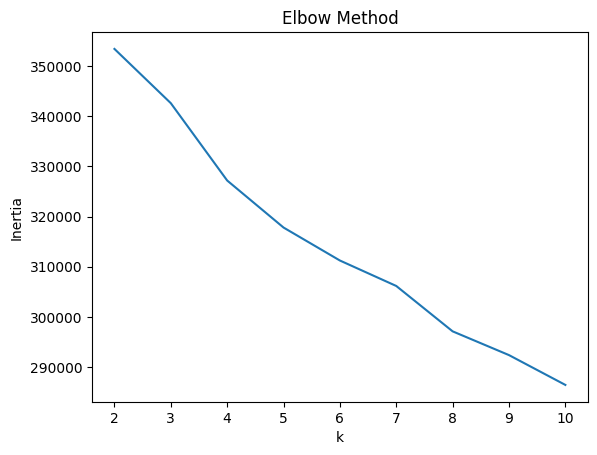

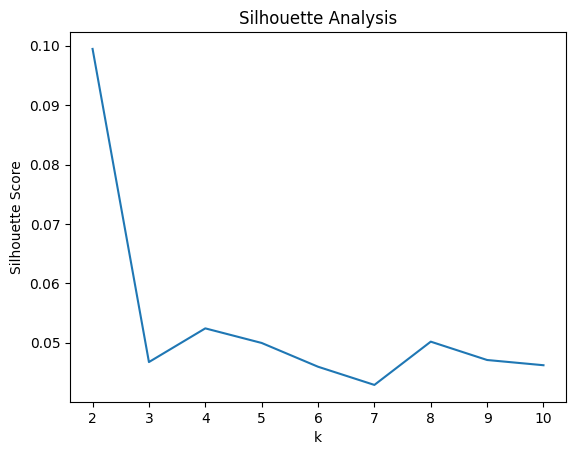

In [ ]:
#Step 6 - Clustering "can we group employees into types"
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Use only numerical features for clustering
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[num_cols])

inertia = []
silhouette_scores = []

k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# Plot Elbow
plt.plot(k_range, inertia)
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

# Plot Silhouette
plt.plot(k_range, silhouette_scores)
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()


In [ ]:
for k, score in zip(range(2, 11), silhouette_scores):
    print(f"k = {k}, silhouette = {score:.4f}")

k = 2, silhouette = 0.0995
k = 3, silhouette = 0.0467
k = 4, silhouette = 0.0524
k = 5, silhouette = 0.0500
k = 6, silhouette = 0.0460
k = 7, silhouette = 0.0429
k = 8, silhouette = 0.0502
k = 9, silhouette = 0.0471
k = 10, silhouette = 0.0462


In [ ]:
# Apply KMeans
# Apply KMeans with k=2
kmeans = KMeans(n_clusters=2, random_state=42)

df["cluster"] = kmeans.fit_predict(X_scaled)

# Check cluster counts
print(df["cluster"].value_counts())

cluster
0    14823
1     5177
Name: count, dtype: int64


In [ ]:
#Find Attrition per Cluster
df.groupby("cluster")["attrition"].apply(lambda x: (x=="Yes").mean())

,attrition
cluster,
0,0.397558
1,0.394051
